# Problem Formulation

The dataset is an ongoing cardiovascular study consisting of 4,240 middle-aged adults (ages 32–70) from Framingham, Massachusetts. It observes a 10-year follow-up period and analyzes whether patients develop or do not develop coronary heart disease within 10 years based on 15 features, including demographic features and health attributes.

Data can be found here: https://www.kaggle.com/datasets/noeyislearning/framingham-heart-study

**Inferential Question**: What is the mean total cholesterol among adults who develop Coronary Heart Disease within 10 years?

In this scenario, the parameter of interest is the true population mean total cholesterol levels among adults who develop coronary heart disease within 10 years, which will be estimated using the sample cholesterol mean from this dataset where TenYearCHD is 1.

**Predictive Task (Regression)**: Can we accurately predict whether an individual will develop coronary heart disease (target variable) within 10 years using all features? List of features:
- Sex 
- Age
- Education
- Smoking status
- Number of cigarettes smoked per day
- Whether a patient is on blood pressure medication or not    
- Whether a patient has had a stroke before or not
- Whether a patient has a history of hypertension or not
- Diabetes status
- Total cholesterol levels
- Systolic blood pressure levels
- Diastolic blood pressure levels
- Body Mass Index
- Heart rate
- Glucose levels

These tasks differ, as the goal of the inferential task will be to quantify uncertainty regarding total cholesterol levels (the population parameter), whereas the goal of the predictive task will be to maximize out-of-sample predictive performance for a future, unseen observation using F-1 score and PR-AUC as the evaluation metrics and binary cross-entropy as the loss function.


# Data Preprocessing

In [1]:
# Importing libraries
import pandas as pd

# Loading the dataset
df = pd.read_csv('data/framingham_heart_study.csv')

df.head()



,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [2]:
# Checking for missing values

print(df.isnull().sum())
print(df.shape)


male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64
(4240, 16)


In [3]:
# Dropping rows with missing values
df.dropna(inplace=True)
print(df.shape)


(3658, 16)


The new sample size is 3658 patients

In [4]:
# Ensuring numeric data types
print(df.dtypes)

male                 int64
age                  int64
education          float64
currentSmoker        int64
cigsPerDay         float64
BPMeds             float64
prevalentStroke      int64
prevalentHyp         int64
diabetes             int64
totChol            float64
sysBP              float64
diaBP              float64
BMI                float64
heartRate          float64
glucose            float64
TenYearCHD           int64
dtype: object


# EDA

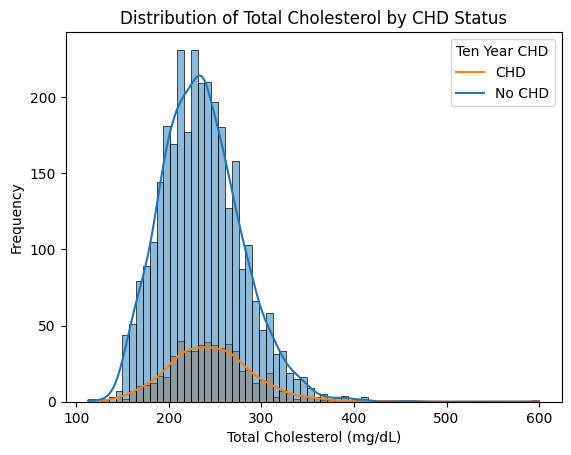

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Distribution of total cholesterol for CHD vs non-CHD

sns.histplot(data=df, x='totChol', hue='TenYearCHD', kde=True)
plt.title('Distribution of Total Cholesterol by CHD Status')
plt.xlabel('Total Cholesterol (mg/dL)')
plt.ylabel('Frequency')
plt.legend(title='Ten Year CHD', labels=['CHD', 'No CHD'])
plt.show()

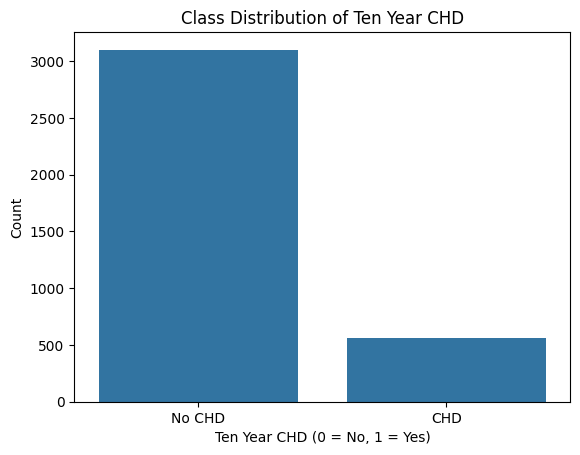

In [6]:
# Plotting class imbalance in the target variable 'TenYearCHD'

sns.countplot(x='TenYearCHD', data=df)
plt.title('Class Distribution of Ten Year CHD')
plt.xlabel('Ten Year CHD (0 = No, 1 = Yes)')
plt.ylabel('Count')
plt.xticks([0, 1], ['No CHD', 'CHD'])
plt.show()

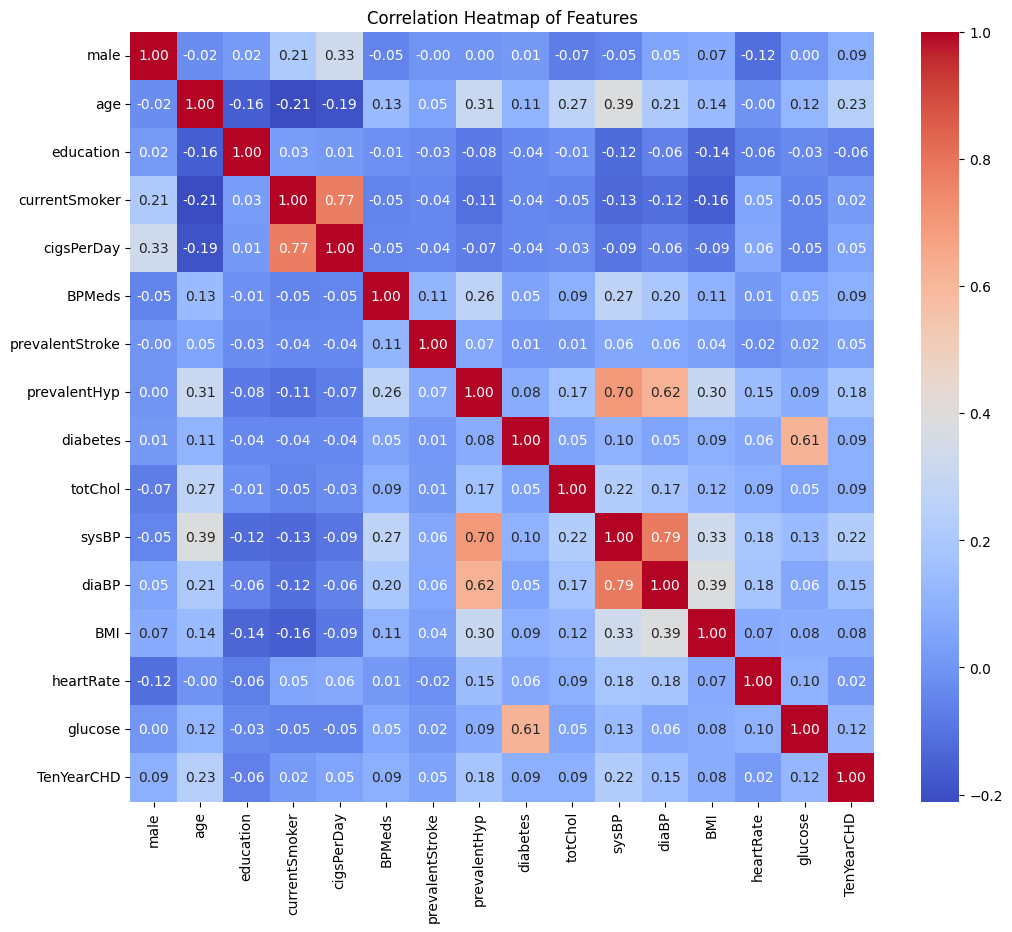

In [7]:
# Correlation heatmap of features
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Heatmap of Features')
plt.show()

# Likelihood and Estimation

In [8]:
# Extracting total cholesterol values for patients with CHD
chol_chd = df[df['TenYearCHD'] == 1]['totChol']
n = len(chol_chd)
print(f"Number of CHD patients: {n}")

Number of CHD patients: 557


### Likelihood Formulation

We model total cholesterol for CHD patients as i.i.d. Normal ($x_i \sim \mathcal{N}(\mu, \sigma^2)$):

$$L(\mu, \sigma^2 \mid x_1, \ldots, x_n) = \prod_{i=1}^{n} \frac{1}{\sqrt{2\pi\sigma^2}} \exp\!\left(-\frac{(x_i - \mu)^2}{2\sigma^2}\right)$$

Maximizing over $\mu$ gives the MLE for the total mean cholesterol level $\hat{\mu} = \bar{x}$, and over $\sigma^2$ gives $\hat{\sigma}^2 = \frac{1}{n}\sum_{i=1}^{n}(x_i - \bar{x})^2$ with 0 delta degrees of freedom (ddof = 0).

### MLE Computation

In [9]:
# Calculating mean and standard deviation of total cholesterol for CHD patients
mu_mle, sigma = chol_chd.mean(), chol_chd.std(ddof = 0)

print(f"MLE for mean cholesterol: {mu_mle:.4f}")

MLE for mean cholesterol: 246.3501


### Likelihood Visualization

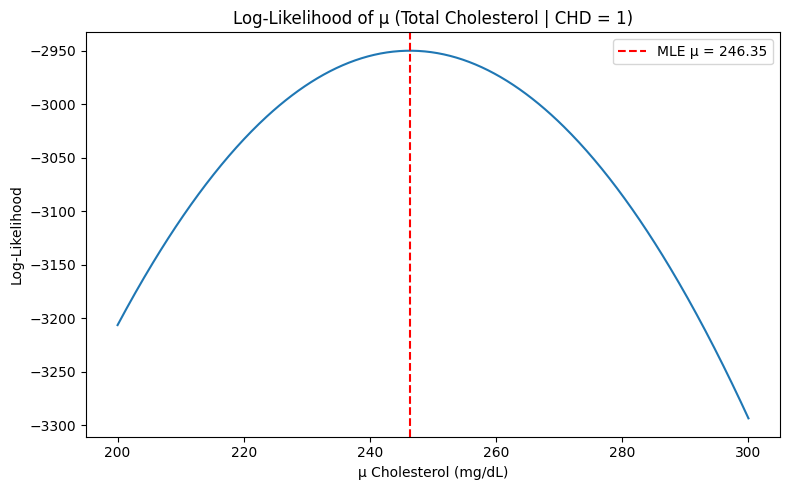

In [10]:
from scipy.stats import norm
import numpy as np

# Range of mu values to evaluate likelihood
mu_range = np.linspace(200, 300, 500)

# Computing log-likelihood for each mu value
log_likelihood = [
    np.sum(norm.logpdf(chol_chd, loc=mu, scale=sigma))
    for mu in mu_range
]

# Plotting log-likelihood as a function of mu
plt.figure(figsize=(8, 5))
plt.plot(mu_range, log_likelihood)
plt.axvline(mu_mle, color='red', linestyle='--', label=f'MLE μ = {mu_mle:.2f}')
plt.title('Log-Likelihood of μ (Total Cholesterol | CHD = 1)')
plt.xlabel('μ Cholesterol (mg/dL)')
plt.ylabel('Log-Likelihood')
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation of Estimator Properties

Given that the distribution of cholesterol values is approximately normal for patients that develop coronary heart disease, the MLE for the mean cholesterol level is the sample mean (246.35 mg/dL), represented by the peak of the above plot. It is an unbiased and a consistent estimator, as increasing sample size will result in the convergence of the sample mean to the true population mean. The MLE for the mean cholesterol level among CHD patients is also the most efficient estimator, as the sample mean has the lowest variance for a normal distribution.

# Frequentist Inference

### Sampling Distribution Reasoning

From the Central Limit Theorem, the sampling distribution of our sample mean is approximately normal, as we have 557 data points which is sufficiently large. The standard error of the mean will represent the variability of the sample mean across repeated samples.

### Theory-based Confidence Interval

In [11]:
from scipy import stats

# Theory-based 95% confidence interval
se = chol_chd.std(ddof=1) / np.sqrt(n)

# Calculating the confidence interval using the t-distribution
ci_lower, ci_upper = stats.t.interval(0.95, df=n-1, loc=mu_mle, scale=se)

print(f"Standard error: {se:.4f} mg/dL")
print(f"95% CI: ({ci_lower:.4f}, {ci_upper:.4f})")

Standard error: 2.0481 mg/dL
95% CI: (242.3272, 250.3730)


### Bootstrap Confidence Interval

In [12]:
# 95% confidence interval using bootstrap

np.random.seed(42)
n_bootstraps = 10000
bootstrap_means = []

# Generating bootstrap samples and calculating mean for each sample
for _ in range(n_bootstraps):
    sample = chol_chd.sample(n=n, replace=True)
    bootstrap_means.append(sample.mean())

bootstrap_means = np.array(bootstrap_means)

# Calculating 95% confidence interval from bootstrap distribution
ci_lower_boot = np.percentile(bootstrap_means, 2.5)
ci_upper_boot = np.percentile(bootstrap_means, 97.5)

print(f"Bootstrap 95% CI: ({ci_lower_boot:.4f}, {ci_upper_boot:.4f})")

Bootstrap 95% CI: (242.4881, 250.4328)


### Hypothesis Testing

We use a hypothesis test (two-sample t-test) to compare the mean cholesterol levels between patients who did not develop coronary heart disease and patients who did develop coronary heart disease within 10 years.

- **Null Hypothesis (H₀):** $\mu_{CHD} = \mu_{no CHD}$
- **Alternative Hypothesis (H₁):** $\mu_{CHD} > \mu_{no CHD}$

In [13]:
# Filtering total cholesterol values for patients without CHD
chol_no_chd = df[df['TenYearCHD'] == 0]['totChol']

# Two-sample t-test for CHD vs non-CHD cholesterol 
t_stat, p_value = stats.ttest_ind(chol_chd, chol_no_chd, alternative='greater')

print(f"CHD mean: {chol_chd.mean():.4f} mg/dL")
print(f"No CHD mean: {chol_no_chd.mean():.4f} mg/dL")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4f}")

CHD mean: 246.3501 mg/dL
No CHD mean: 235.1409 mg/dL
T-statistic: 5.5459
P-value: 0.0000


### Interpretation of results

The confidence level of 95% used in both the theory-based and bootstrap confidence intervals indicates that, if we repeated this sampling procedure many times, 95% of intervals would contain the true population mean cholesterol among adults who develop coronary heart disease within 10 years. The theory-based 95% confidence interval of (242.33, 250.37) mg/dL and the bootstrap 95% confidence interval of (242.4881, 250.4328) mg/dL reflect extremely similar ranges of values for the population mean cholesterol level, quantifying our uncertainty around μ.

The p-value of ~0 is less than 0.05, meaning that we reject the null hypothesis, as evidence supports the mean cholesterol levels for patients who develop coronary heart disease within 10 years to be greater than mean cholesterol levels for those who do not. The T-statistic of ~ 5.55 indicates that the observed data would be very unlikely to occur if the null hypothesis were true, suggesting statistical significance in the alternative hypothesis. 

# Bayesian Estimation

### Prior Distribution Choice

We model the population mean cholesterol μ with a Normal prior: μ ~ N(μ₀, σ₀²). We set our prior before looking at any CHD-specific data, using clinical guidelines as context. The American Heart Association defines 200 mg/dL as the upper boundary of desirable total cholesterol in adults, so we center our prior there. We use σ₀ = 30 to reflect some uncertainty, allowing for possible prior values from roughly 140 to 260 mg/dL.
- **Prior mean (μ₀ = 200):** based on AHA cholesterol threshold
- **Prior std (σ₀ = 30):** reflects uncertainty across the general adult population

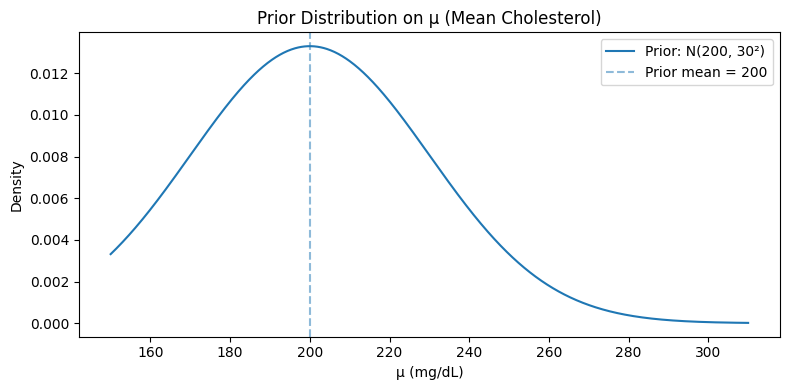

In [16]:
# Prior parameters
mu_0 = 200
sigma_0 = 30

# Grid of mu values
mu_grid = np.linspace(150, 310, 1000)

# Prior distribution
prior = norm.pdf(mu_grid, loc=mu_0, scale=sigma_0)

# Plot the prior
plt.figure(figsize=(8, 4))
plt.plot(mu_grid, prior, label=f'Prior: N({mu_0}, {sigma_0}²)')
plt.axvline(mu_0, linestyle='--', alpha=0.5, label=f'Prior mean = {mu_0}')
plt.title('Prior Distribution on μ (Mean Cholesterol)')
plt.xlabel('μ (mg/dL)')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.show()

### Posterior Computation

Because we chose a normal prior and our likelihood is also normal, this is a 
conjugate model, meaning the posterior is also normal with a closed-form solution.

The posterior update equations are:
- **Posterior precision:** 1/σₙ² = n/σ² + 1/σ₀²
- **Posterior mean:** μₙ = σₙ² × (n·x̄/σ² + μ₀/σ₀²)

The posterior is then: μ | x ~ N(μₙ, σₙ²)

In [21]:
# Posterior precision
precision_posterior = (n / sigma**2) + (1 / sigma_0**2)
sigma_n = np.sqrt(1 / precision_posterior)

# Posterior mean
mu_n = (1 / precision_posterior) * (
    (n * mu_mle / sigma**2) + (mu_0 / sigma_0**2)
)

print(f"Posterior mean: {mu_n:.4f} mg/dL")
print(f"Posterior std:  {sigma_n:.4f} mg/dL")

Posterior mean: 246.1355 mg/dL
Posterior std:  2.0415 mg/dL


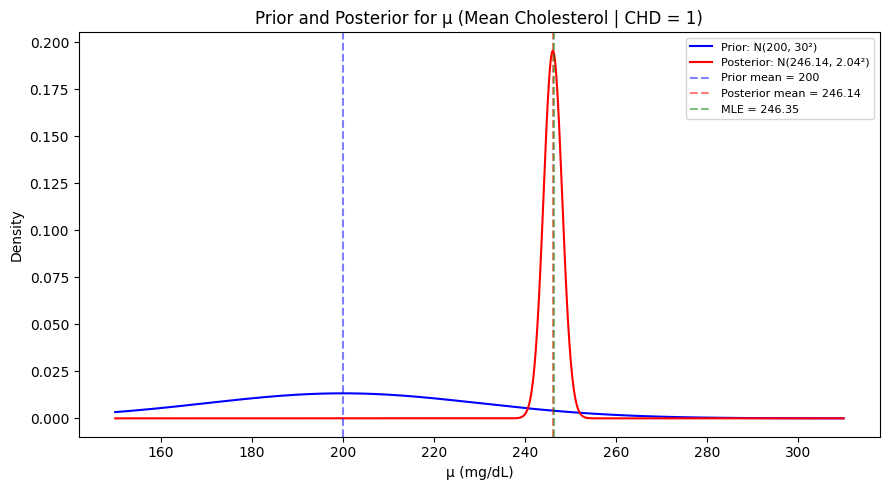

In [22]:
# Compute distributions over the grid
prior_dist = norm.pdf(mu_grid, loc=mu_0, scale=sigma_0)
posterior_dist = norm.pdf(mu_grid, loc=mu_n, scale=sigma_n)

plt.figure(figsize=(9, 5))
plt.plot(mu_grid, prior_dist,     color='blue', label=f'Prior: N({mu_0}, {sigma_0}²)')
plt.plot(mu_grid, posterior_dist, color='red',  label=f'Posterior: N({mu_n:.2f}, {sigma_n:.2f}²)')
plt.axvline(mu_0,   color='blue', linestyle='--', alpha=0.5, label=f'Prior mean = {mu_0}')
plt.axvline(mu_n,   color='red',  linestyle='--', alpha=0.5, label=f'Posterior mean = {mu_n:.2f}')
plt.axvline(mu_mle, color='green',linestyle='--', alpha=0.5, label=f'MLE = {mu_mle:.2f}')
plt.title('Prior and Posterior for μ (Mean Cholesterol | CHD = 1)')
plt.xlabel('μ (mg/dL)')
plt.ylabel('Density')
plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

### 95% Credible Interval

In [23]:
ci_lower_bayes = norm.ppf(0.025, loc=mu_n, scale=sigma_n)
ci_upper_bayes = norm.ppf(0.975, loc=mu_n, scale=sigma_n)

print(f"95% Credible Interval: ({ci_lower_bayes:.4f}, {ci_upper_bayes:.4f}) mg/dL")

95% Credible Interval: (242.1342, 250.1367) mg/dL


### Bayesian vs. Frequentist Comparison

The bootstrap CI (242.49, 250.43) and Bayesian credible interval (242.14, 250.14) are nearly identical in width and center, which is expected given the large sample size (n = 557). The only notable difference is that the Bayesian posterior mean (246.14 mg/dL) is very slightly lower than the MLE (246.35 mg/dL), reflecting the small pull of our prior toward 200 mg/dL. This influence is largely overwhelmed by the data. The key distinction comes from how we interpret each of them. A frequentist CI means that if we repeated this sampling procedure many times, 95% of the intervals would contain the true parameter. A Bayesian credible interval means there is a 95% probability that the parameter itself lies within the interval, given the data we observed. This is a more intuitive and direct statement about uncertainty.

# Prediction and Model Evaluation

### Train/Test Split

We split the data into 80% training and 20% test sets to evaluate predictive performance. The target variable is TenYearCHD (binary), and all remaining features are used as predictors.

In [26]:
from sklearn.model_selection import train_test_split

# Define features and target
X = df.drop(columns=['TenYearCHD'])
y = df['TenYearCHD']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Training set size: 2926
Test set size: 732


### Logistic Regression Model

We fit a logistic regression model on the training set to predict the probability that a patient develops coronary heart disease within 10 years.

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Standardize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fitting model
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


### Model Evaluation: ROC Curve and AUC

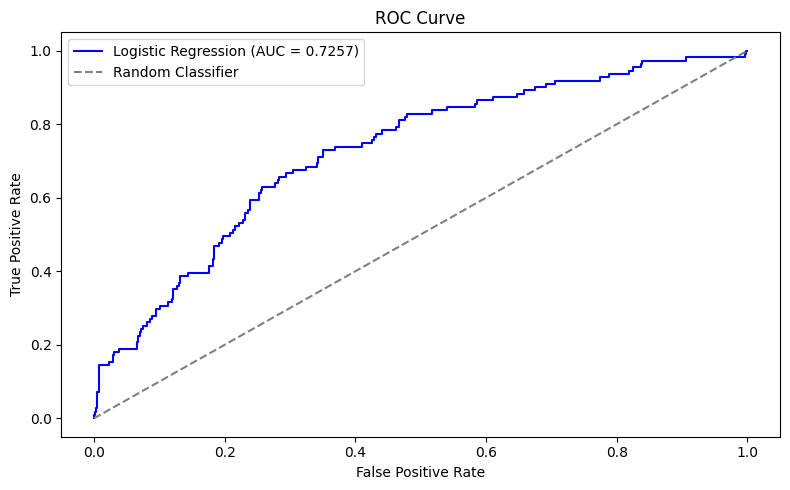

AUC Score: 0.7257


In [28]:
from sklearn.metrics import roc_curve, roc_auc_score

# Getting predicted probabilities on test set
y_pred_prob = log_reg.predict_proba(X_test_scaled)[:, 1]

# Computing ROC curve and AUC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
auc_score = roc_auc_score(y_test, y_pred_prob)

# Plotting ROC curve
plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, color='blue', label=f'Logistic Regression (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.show()

print(f"AUC Score: {auc_score:.4f}")

### Interpretation

The logistic regression model achieves an AUC of 0.7257, meaning it correctly distinguishes between patients who develop CHD and those who do not about 73% of the time. This is a meaningful improvement over a random classifier which would be 0.5, suggesting that the features we trained the model on carry real predictive signal for CHD risk. However, the model is far from perfect, which is expected given how complex cardiovascular disease and the noise in health data is. The ROC curve rising steeply in the lower left indicates that the model performs best when a low false positive rate is prioritized.